In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset_WIFI7.csv')
df.head()

,Frequency(GHz),length of patch in mm,length of patch in mm.1,length of substrate in mm,width of Substrate in mm,Area of Slots(mm^2),Radiaus of Circular Slot(mm),S11(dB)
0,2.000,27,38,59,76,58.2656,4,-0.542108
1,2.005,27,38,59,76,58.2656,4,-0.580837
2,2.010,27,38,59,76,58.2656,4,-0.621691
3,2.015,27,38,59,76,58.2656,4,-0.663752
4,2.020,27,38,59,76,58.2656,4,-0.706049


In [ ]:
df.isna().sum()

,0
Frequency(GHz),0
length of patch in mm,0
length of patch in mm.1,0
length of substrate in mm,0
width of Substrate in mm,0
Area of Slots(mm^2),0
Radiaus of Circular Slot(mm),0
S11(dB),0


In [ ]:
df['Frequency(GHz)'].value_counts()

,count
Frequency(GHz),
7.000,3
2.000,3
2.005,3
2.010,3
2.015,3
...,...
2.065,3
2.060,3
2.055,3


In [ ]:
df.columns

Index(['Frequency(GHz)', 'length of patch in mm', 'length of patch in mm.1',
       'length of substrate in mm', 'width of Substrate in mm',
       'Area of Slots(mm^2)', 'Radiaus of Circular Slot(mm)', 'S11(dB)'],
      dtype='object')

In [ ]:
df.shape

(3003, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3003 entries, 0 to 3002
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Frequency(GHz)                3003 non-null   float64
 1   length of patch in mm         3003 non-null   int64  
 2   length of patch in mm.1       3003 non-null   int64  
 3   length of substrate in mm     3003 non-null   int64  
 4   width of Substrate in mm      3003 non-null   int64  
 5   Area of Slots(mm^2)           3003 non-null   float64
 6   Radiaus of Circular Slot(mm)  3003 non-null   int64  
 7   S11(dB)                       3003 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 187.8 KB


In [ ]:
df.describe()

,Frequency(GHz),length of patch in mm,length of patch in mm.1,length of substrate in mm,width of Substrate in mm,Area of Slots(mm^2),Radiaus of Circular Slot(mm),S11(dB)
count,3003.000000,3003.0,3003.0,3003.000000,3003.000000,3003.000000,3003.0,3003.000000
mean,4.500000,27.0,38.0,61.000000,72.333333,61.598400,4.0,-4.198879
std,1.445059,0.0,0.0,2.828898,5.186313,4.714076,0.0,4.786096
min,2.000000,27.0,38.0,59.000000,65.000000,58.265600,4.0,-36.845910
25%,3.250000,27.0,38.0,59.000000,65.000000,58.265600,4.0,-4.181228
50%,4.500000,27.0,38.0,59.000000,76.000000,58.265600,4.0,-2.512452
75%,5.750000,27.0,38.0,65.000000,76.000000,68.264000,4.0,-1.885008
max,7.000000,27.0,38.0,65.000000,76.000000,68.264000,4.0,-0.453002


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns = df.columns.str.lower()
df.head(3)

,frequency(ghz),length of patch in mm,length of patch in mm.1,length of substrate in mm,width of substrate in mm,area of slots(mm^2),radiaus of circular slot(mm),s11(db)
0,2.000,27,38,59,76,58.2656,4,-0.542108
1,2.005,27,38,59,76,58.2656,4,-0.580837
2,2.010,27,38,59,76,58.2656,4,-0.621691


In [ ]:
df.columns

Index(['frequency(ghz)', 'length of patch in mm', 'length of patch in mm.1',
       'length of substrate in mm', 'width of substrate in mm',
       'area of slots(mm^2)', 'radiaus of circular slot(mm)', 's11(db)'],
      dtype='object')

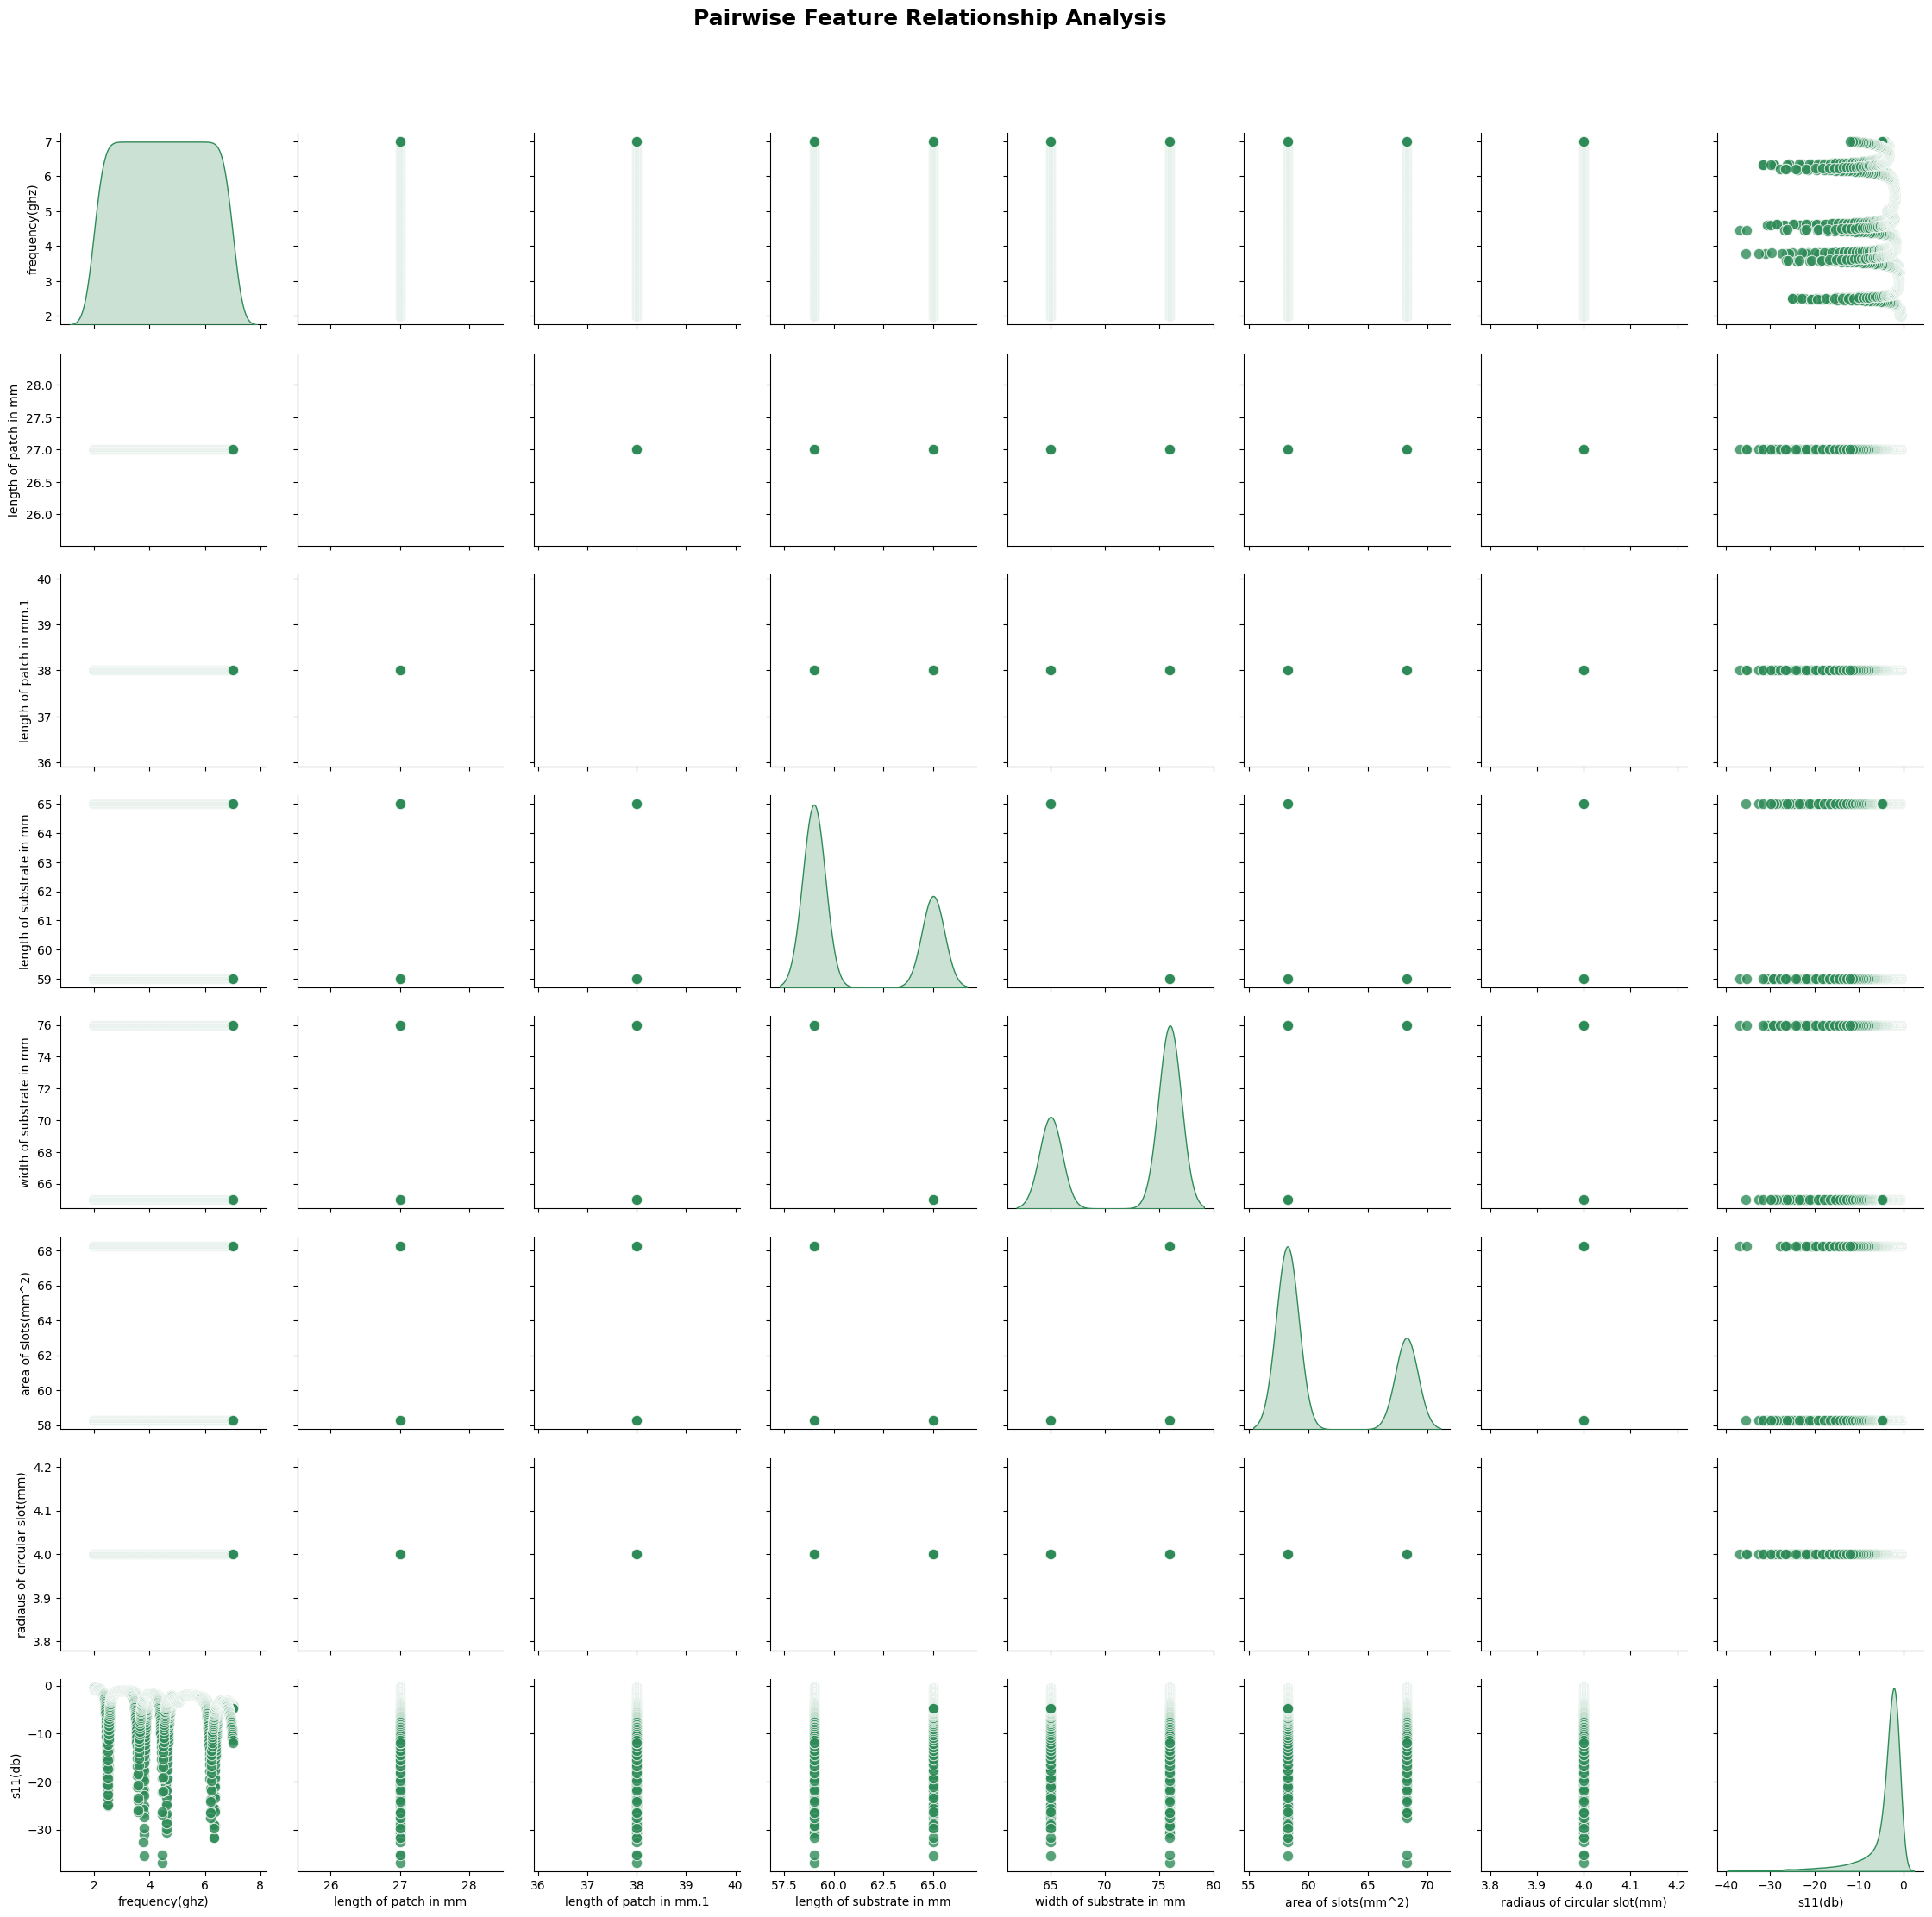

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create pairplot with full space usage
g = sns.pairplot(
    df,
    diag_kind="kde",
    height=3,
    aspect=1,
    plot_kws={
        "color": "seagreen",
        "alpha": 0.8,
        "s": 80
    },
    diag_kws={
        "color": "seagreen",
        "fill": True
    }
)

# Increase plot area and reduce gaps
g.fig.subplots_adjust(
    top=0.92,
    bottom=0.08,
    left=0.08,
    right=0.98,
    hspace=0.15,
    wspace=0.15
)

g.fig.suptitle(
    "Pairwise Feature Relationship Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.show()

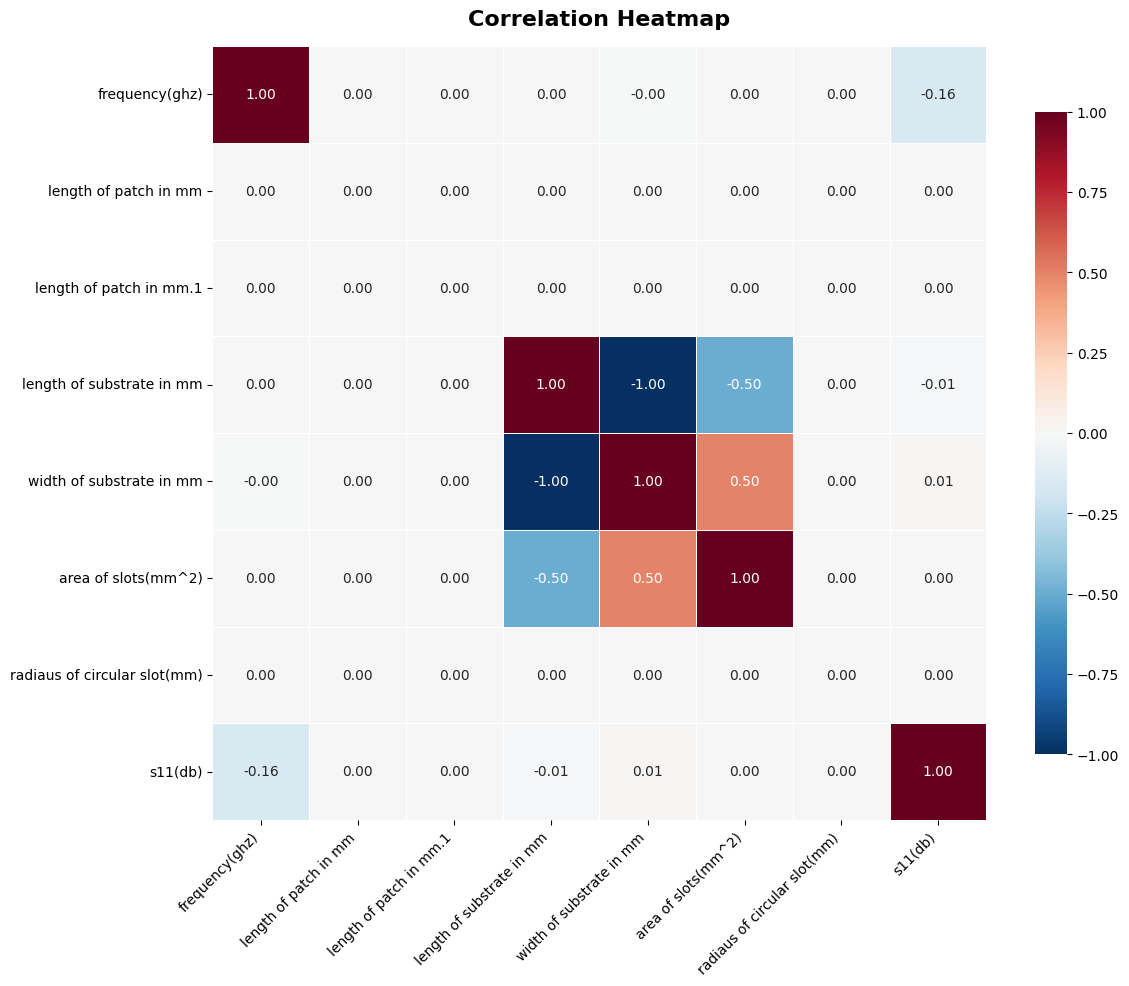

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation and remove missing values
corr = df.corr(numeric_only=True).fillna(0)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    fmt=".2f",
    linewidths=0.5,
    square=True,          # Fill cells equally
    cbar_kws={"shrink":0.8}
)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

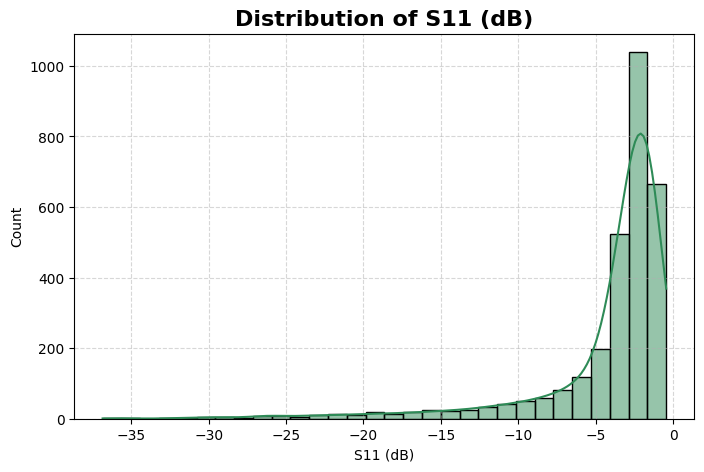

In [ ]:
# Distribution of the target (s11(db))
plt.figure(figsize=(8, 5))
sns.histplot(df['s11(db)'], kde=True, bins=30, color='seagreen')

plt.title('Distribution of S11 (dB)', fontsize=16, fontweight='bold')
plt.xlabel('S11 (dB)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

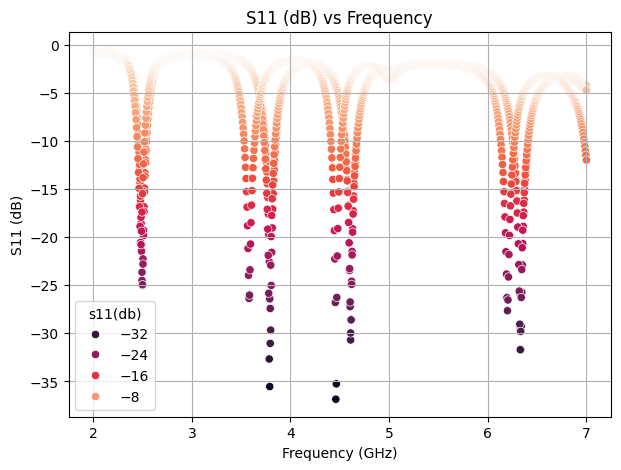

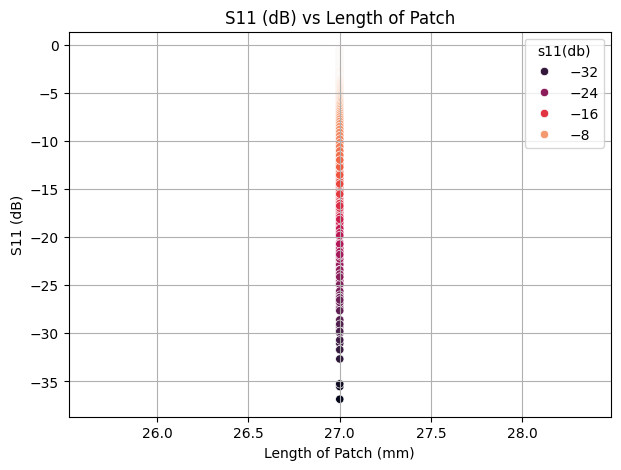

In [ ]:
# Scatter plot of s11 vs frequency
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='frequency(ghz)', y='s11(db)', hue='s11(db)', palette='rocket')
plt.title('S11 (dB) vs Frequency')
plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 (dB)')
plt.grid(True)
plt.show()

# Scatter plot of s11 vs length of patch
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='length of patch in mm', y='s11(db)', hue='s11(db)', palette='rocket')
plt.title('S11 (dB) vs Length of Patch')
plt.xlabel('Length of Patch (mm)')
plt.ylabel('S11 (dB)')
plt.grid(True)
plt.show()

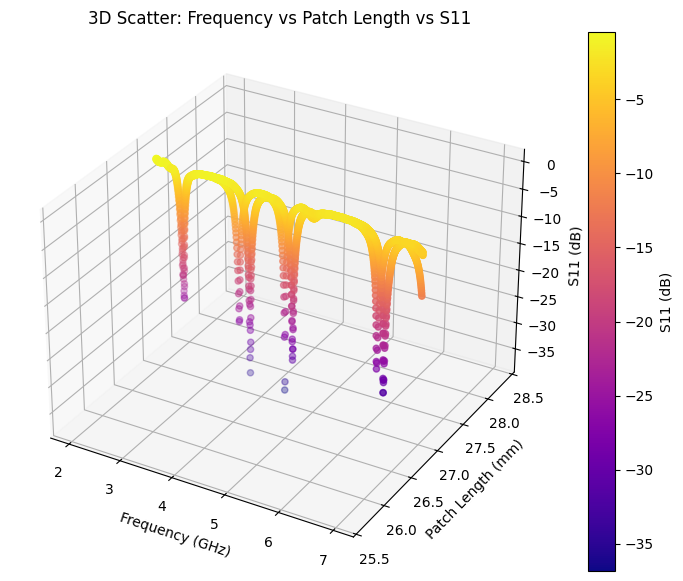

In [ ]:
# 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x = df['frequency(ghz)']
y = df['length of patch in mm']
z = df['s11(db)']

sc = ax.scatter(x, y, z, c=z, cmap='plasma')

ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Patch Length (mm)')
ax.set_zlabel('S11 (dB)')
ax.set_title('3D Scatter: Frequency vs Patch Length vs S11')

fig.colorbar(sc, label='S11 (dB)')
plt.show()

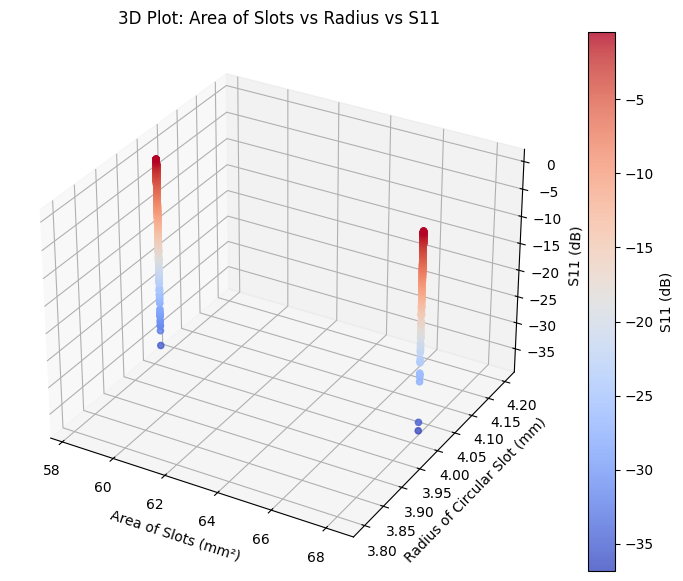

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x = df['area of slots(mm^2)']
y = df['radiaus of circular slot(mm)']
z = df['s11(db)']

sc = ax.scatter(x, y, z, c=z, cmap='coolwarm', alpha=0.8)

ax.set_xlabel('Area of Slots (mm²)')
ax.set_ylabel('Radius of Circular Slot (mm)')
ax.set_zlabel('S11 (dB)')
ax.set_title('3D Plot: Area of Slots vs Radius vs S11')

fig.colorbar(sc, label='S11 (dB)')
plt.show()

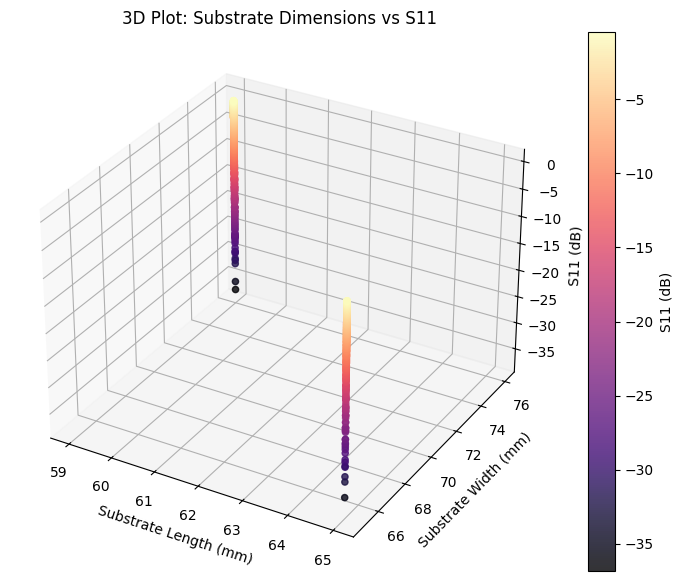

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x = df['length of substrate in mm']
y = df['width of substrate in mm']
z = df['s11(db)']

sc = ax.scatter(x, y, z, c=z, cmap='magma', alpha=0.8)

ax.set_xlabel('Substrate Length (mm)')
ax.set_ylabel('Substrate Width (mm)')
ax.set_zlabel('S11 (dB)')
ax.set_title('3D Plot: Substrate Dimensions vs S11')

fig.colorbar(sc, label='S11 (dB)')
plt.show()

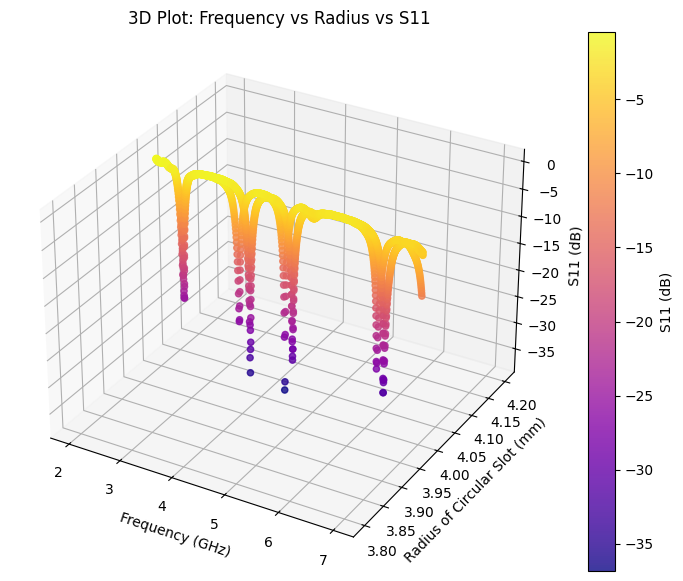

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x = df['frequency(ghz)']
y = df['radiaus of circular slot(mm)']
z = df['s11(db)']

sc = ax.scatter(x, y, z, c=z, cmap='plasma', alpha=0.8)

ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Radius of Circular Slot (mm)')
ax.set_zlabel('S11 (dB)')
ax.set_title('3D Plot: Frequency vs Radius vs S11')

fig.colorbar(sc, label='S11 (dB)')
plt.show()

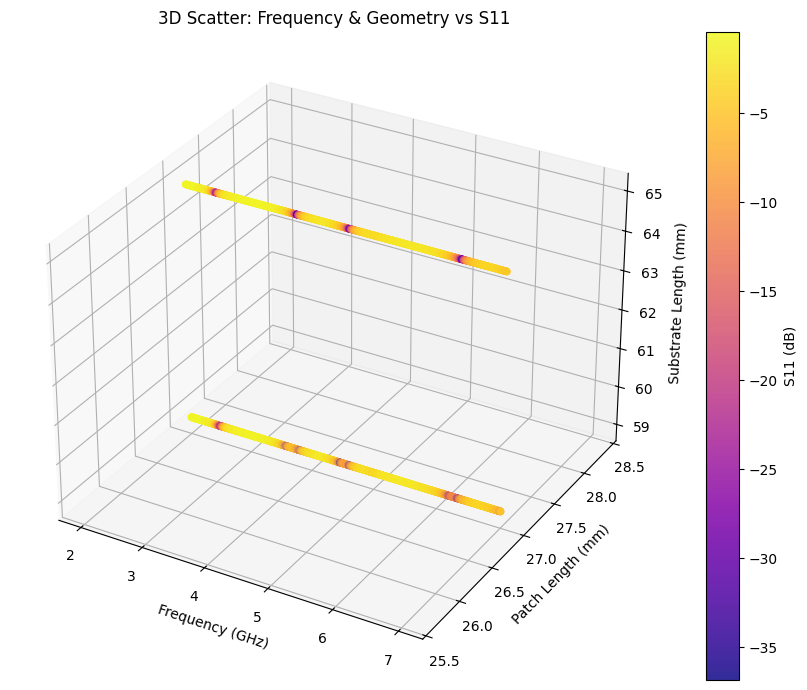

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x = df['frequency(ghz)']
y = df['length of patch in mm']
z = df['length of substrate in mm']
color = df['s11(db)']

sc = ax.scatter(x, y, z, c=color, cmap='plasma', alpha=0.85)

ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Patch Length (mm)')
ax.set_zlabel('Substrate Length (mm)')
ax.set_title('3D Scatter: Frequency & Geometry vs S11')

fig.colorbar(sc, label='S11 (dB)')
plt.tight_layout()
plt.show()

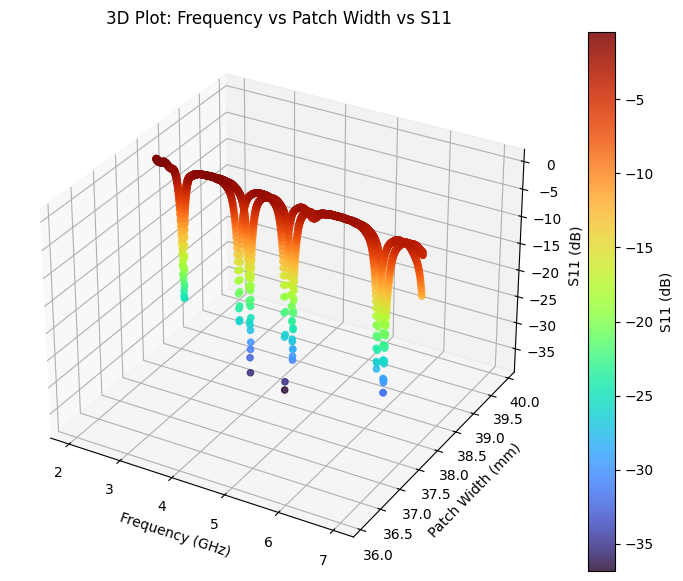

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x = df['frequency(ghz)']
y = df['length of patch in mm.1']
z = df['s11(db)']

sc = ax.scatter(x, y, z, c=z, cmap='turbo', alpha=0.85)

ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Patch Width (mm)')
ax.set_zlabel('S11 (dB)')
ax.set_title('3D Plot: Frequency vs Patch Width vs S11')

fig.colorbar(sc, label='S11 (dB)')
plt.show()

In [ ]:
x = df.drop(['s11(db)'], axis=1)
y = df['s11(db)']

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(x)
X = scaled_features

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **Standardization**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Standardize the training and testing data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("=" * 50)
print("Feature Standardization Completed Successfully")
print("=" * 50)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Feature Standardization Completed Successfully
Training Data Shape: (2402, 7)
Testing Data Shape : (601, 7)


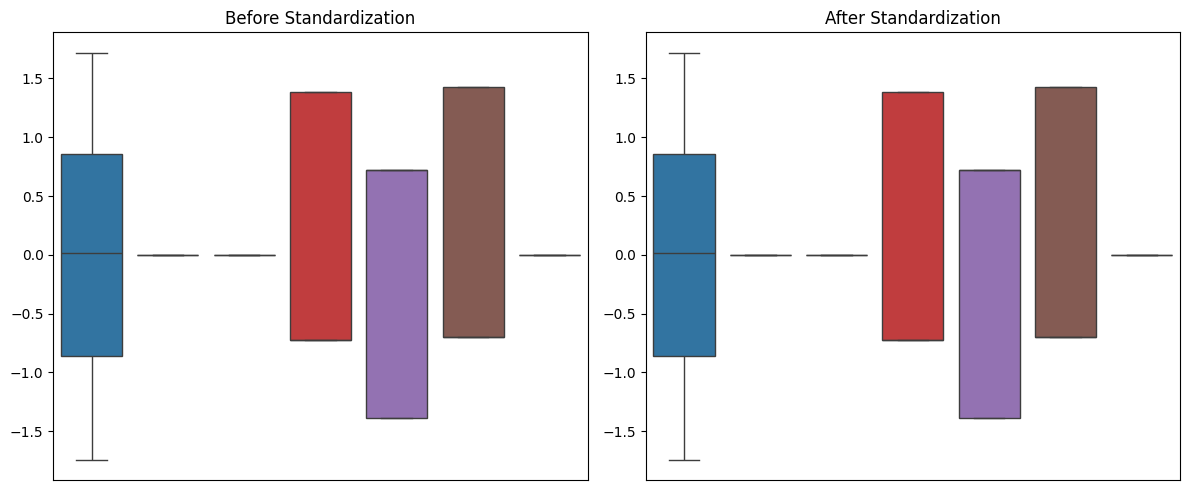

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title("Before Standardization")
plt.xticks([])

plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title("After Standardization")
plt.xticks([])

plt.tight_layout()
plt.show()

# **Data cleaning process**

In [ ]:
import pandas as pd

# Check dataset information
print(df.info())

# Check missing values
print(df.isnull().sum())

# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing numerical values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill missing categorical values with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify data cleaning
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDuplicate Rows After Cleaning:")
print(df.duplicated().sum())

print("\nData Cleaning Completed Successfully.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3003 entries, 0 to 3002
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   frequency(ghz)                3003 non-null   float64
 1   length of patch in mm         3003 non-null   int64  
 2   length of patch in mm.1       3003 non-null   int64  
 3   length of substrate in mm     3003 non-null   int64  
 4   width of substrate in mm      3003 non-null   int64  
 5   area of slots(mm^2)           3003 non-null   float64
 6   radiaus of circular slot(mm)  3003 non-null   int64  
 7   s11(db)                       3003 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 187.8 KB
None
frequency(ghz)                  0
length of patch in mm           0
length of patch in mm.1         0
length of substrate in mm       0
width of substrate in mm        0
area of slots(mm^2)             0
radiaus of circular slot(mm)    0
s11(db)  

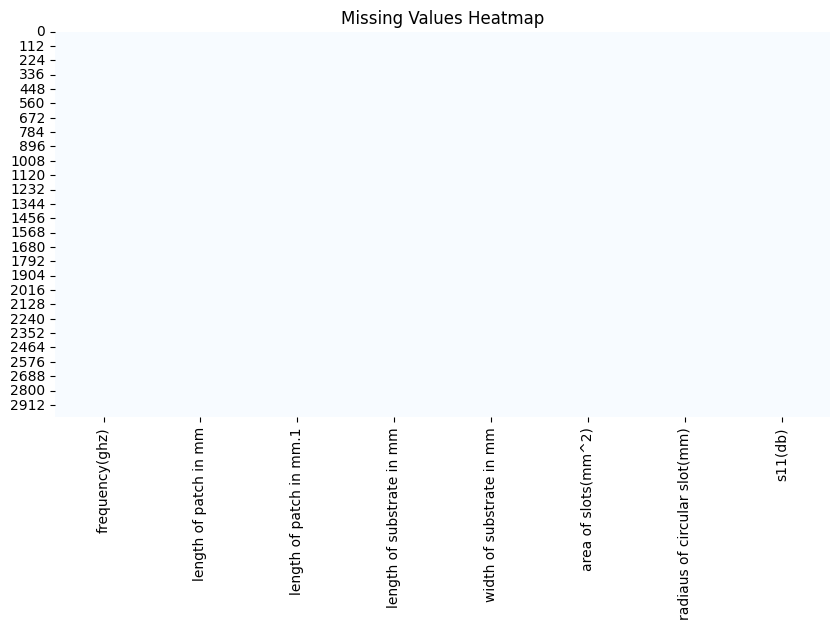

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="Blues")
plt.title("Missing Values Heatmap")
plt.show()

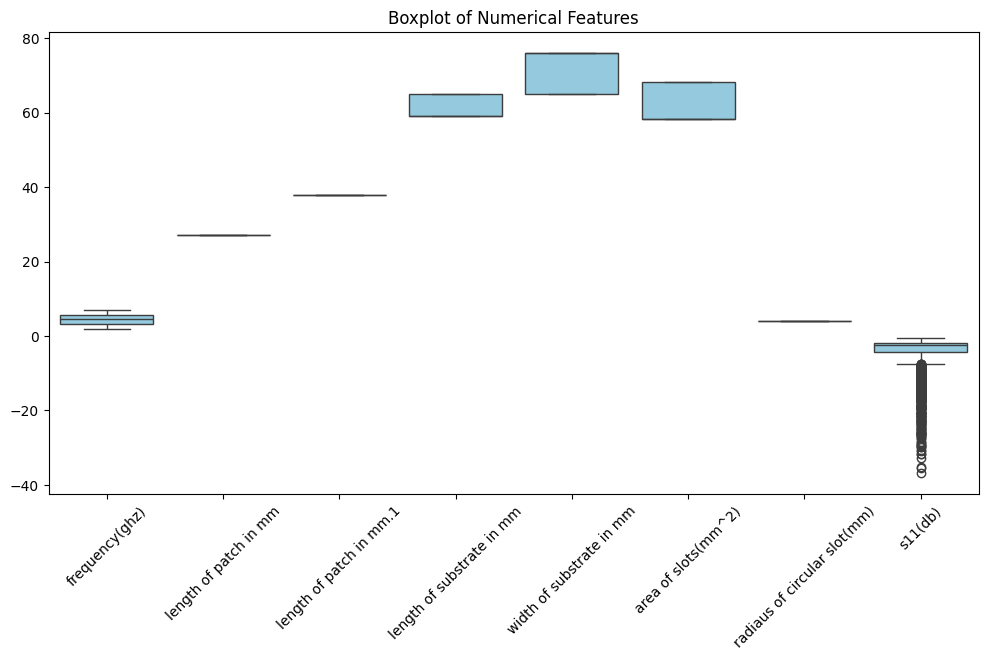

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number'), color="skyblue")
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

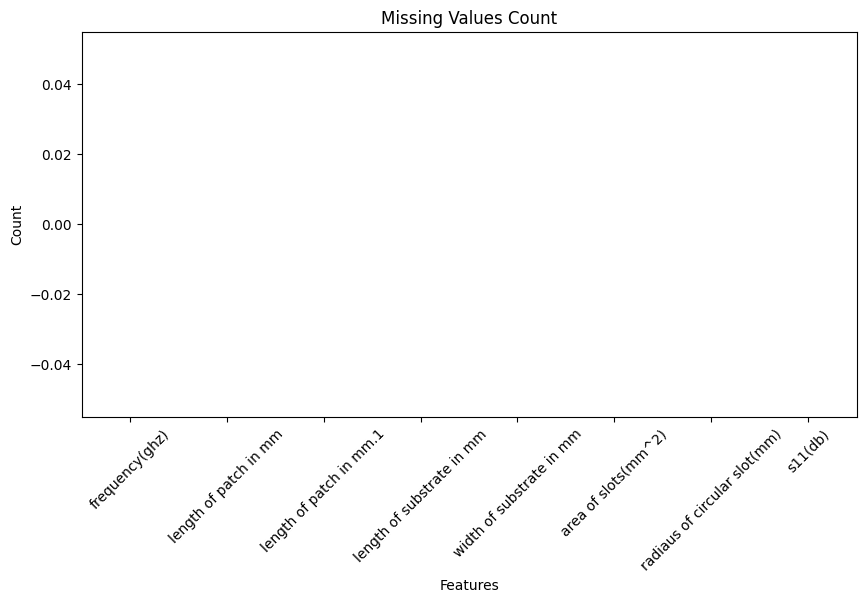

In [ ]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()

plt.figure(figsize=(10, 5))
missing.plot(kind='bar', color='steelblue')
plt.title("Missing Values Count")
plt.xlabel("Features")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# **Min-Max Scaling**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize Min-Max Scaler
scaler = MinMaxScaler()

# Apply Min-Max Scaling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Min-Max Scaling Completed Successfully.")
print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape :", X_test_scaled.shape)

Min-Max Scaling Completed Successfully.
Training Data Shape: (2402, 7)
Testing Data Shape : (601, 7)


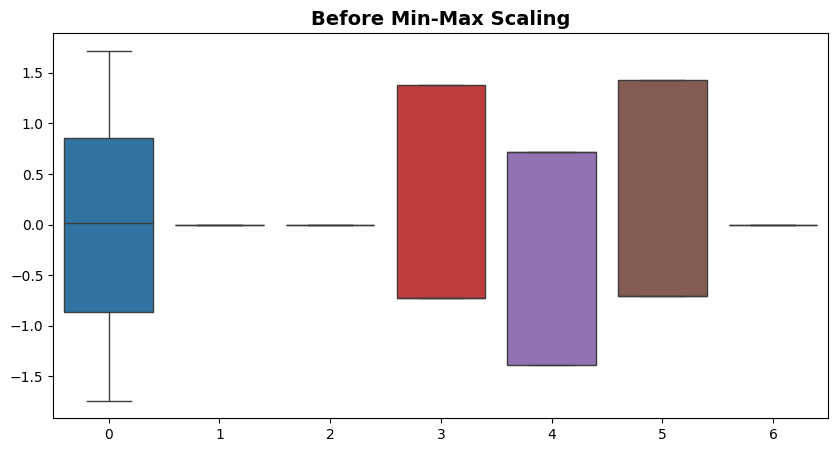

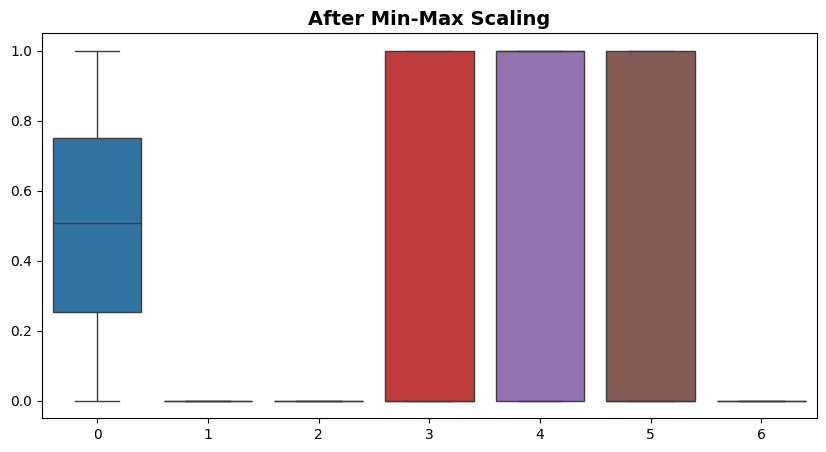

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Before Min-Max Scaling
plt.figure(figsize=(10, 5))
sns.boxplot(data=X_train)
plt.title("Before Min-Max Scaling", fontsize=14, fontweight="bold")
plt.show()

# Apply Min-Max Scaling
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# After Min-Max Scaling
plt.figure(figsize=(10, 5))
sns.boxplot(data=X_train_scaled)
plt.title("After Min-Max Scaling", fontsize=14, fontweight="bold")
plt.show()

# **One-Hot Encoding**

In [ ]:
import pandas as pd

# Apply One-Hot Encoding to categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Display the encoded dataset information
print("One-Hot Encoding Completed Successfully.")
print(df_encoded.info())

One-Hot Encoding Completed Successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3003 entries, 0 to 3002
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   frequency(ghz)                3003 non-null   float64
 1   length of patch in mm         3003 non-null   int64  
 2   length of patch in mm.1       3003 non-null   int64  
 3   length of substrate in mm     3003 non-null   int64  
 4   width of substrate in mm      3003 non-null   int64  
 5   area of slots(mm^2)           3003 non-null   float64
 6   radiaus of circular slot(mm)  3003 non-null   int64  
 7   s11(db)                       3003 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 187.8 KB
None


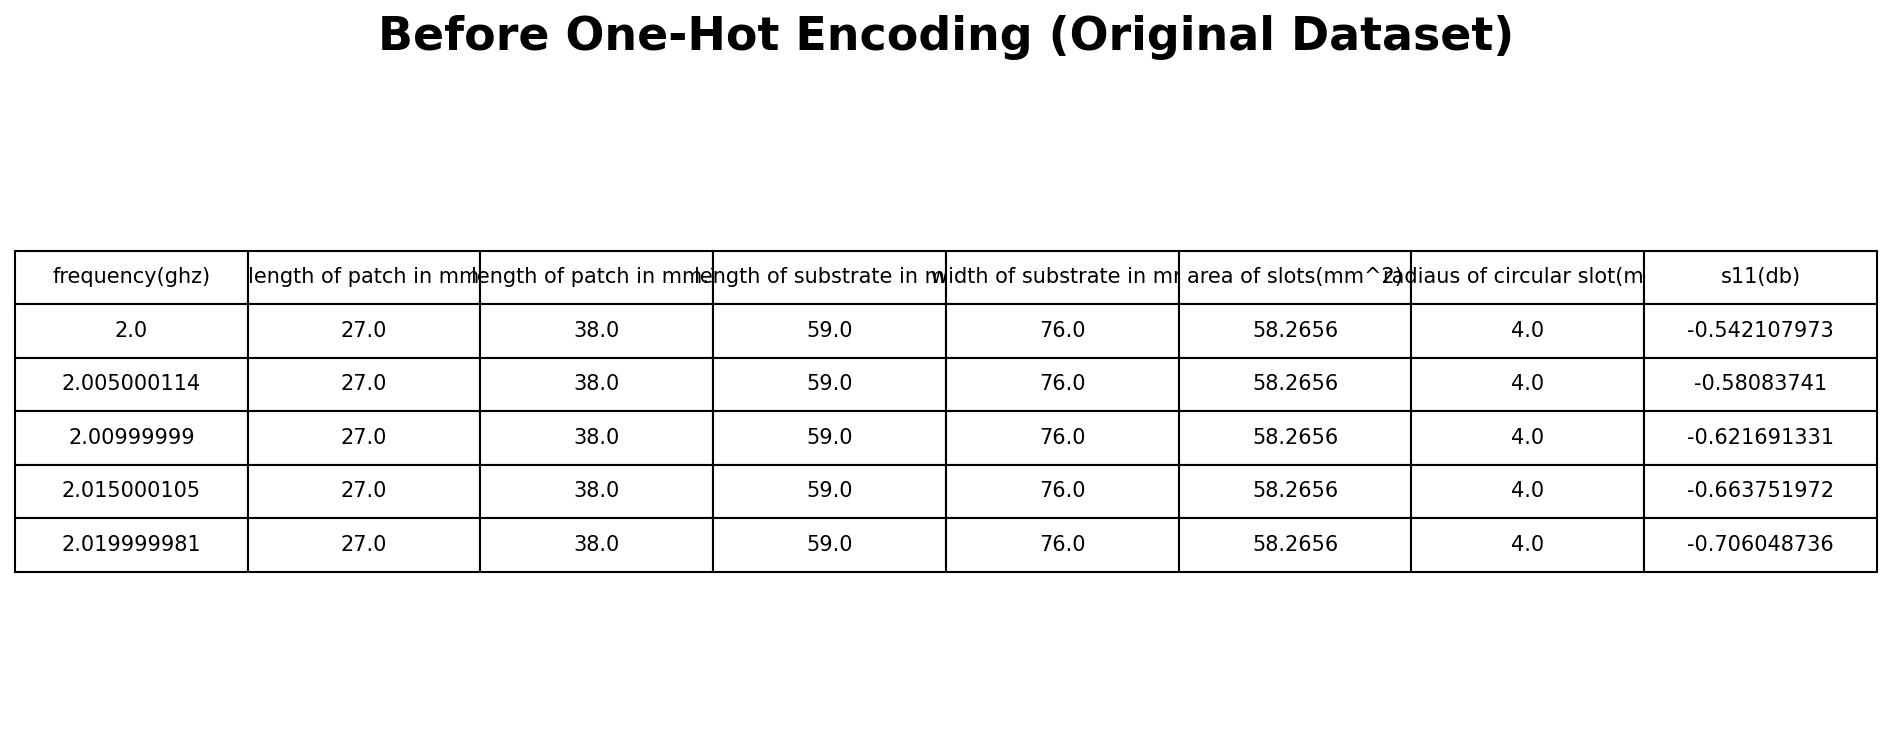

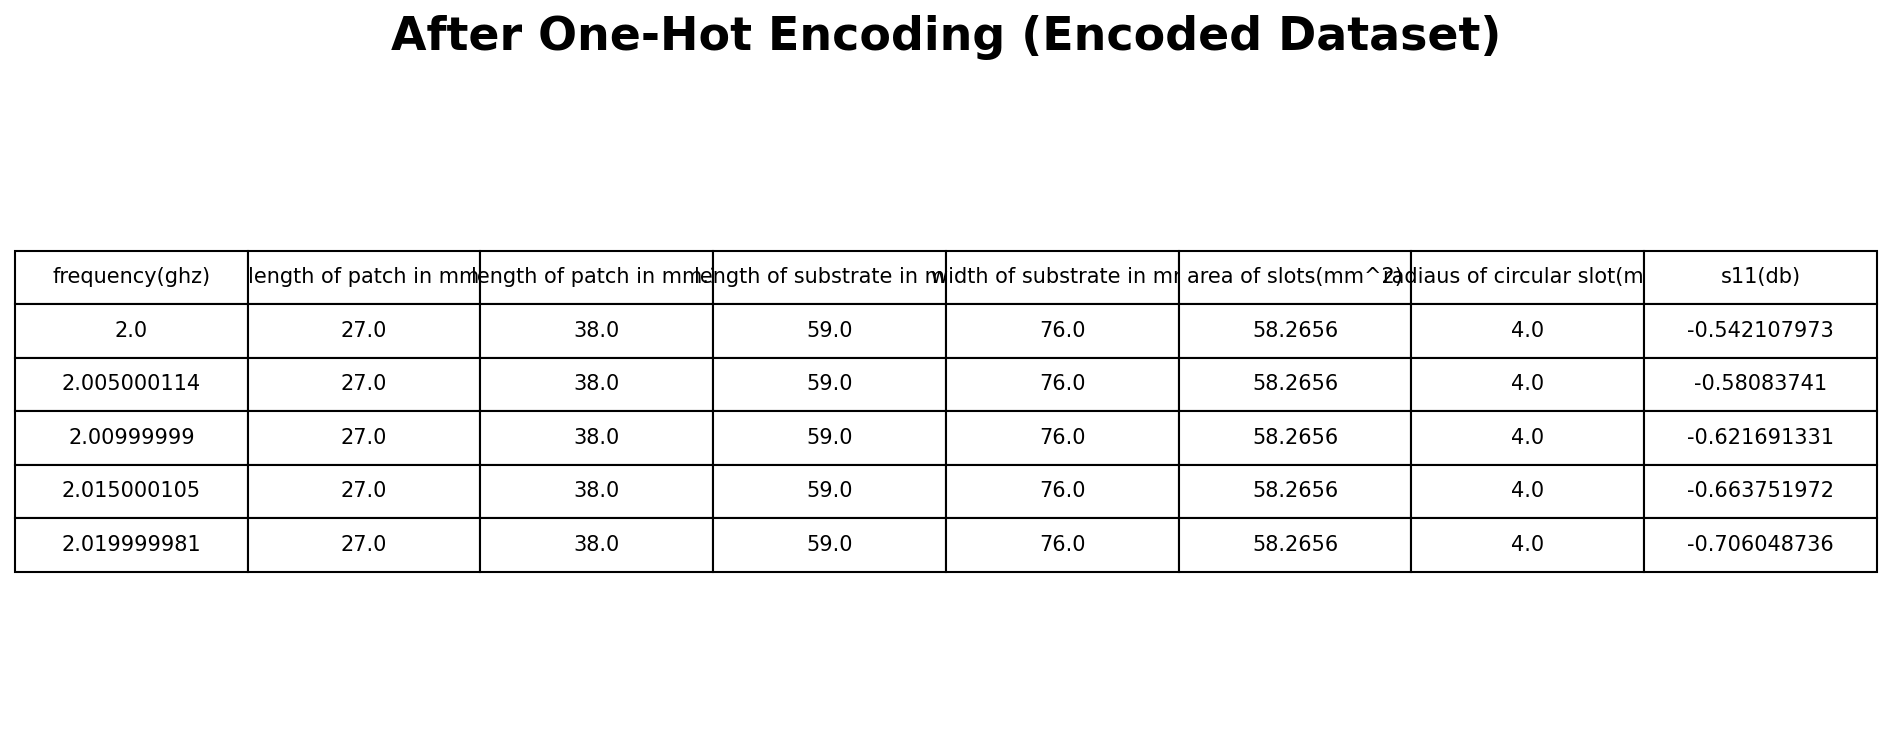

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)


# Take sample rows
original_sample = df.head(5)
encoded_sample = df_encoded.head(5)


# Function to create table visualization
def create_table(data, title):

    fig, ax = plt.subplots(figsize=(14, 5), dpi=150)

    ax.axis("off")

    table = ax.table(
        cellText=data.values,
        colLabels=data.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.5, 2)

    plt.title(
        title,
        fontsize=22,
        fontweight="bold",
        pad=25
    )

    plt.tight_layout()
    plt.show()



create_table(
    original_sample,
    "Before One-Hot Encoding (Original Dataset)"
)


create_table(
    encoded_sample,
    "After One-Hot Encoding (Encoded Dataset)"
)

# **Feature extraction**

In [ ]:
# ==========================================
# Feature Extraction using Rényi Entropy
# ==========================================

import pandas as pd
import numpy as np


# Dataset information
print("Dataset Shape:")
print(df.shape)

print("\nDataset Columns:")
print(df.columns)


# ==============================
# Select Numerical Features
# ==============================

X = df.select_dtypes(include=['int64','float64'])


print("\nFeatures Used:")
print(X.columns)


# ==============================
# Rényi Entropy Function
# ==============================

def renyi_entropy(feature, alpha=2):

    # Create probability distribution
    hist, bins = np.histogram(
        feature,
        bins=20,
        density=True
    )

    # Normalize probabilities
    prob = hist / np.sum(hist)

    # Remove zero probabilities
    prob = prob[prob > 0]

    # Rényi entropy formula
    entropy = (
        1 / (1 - alpha)
    ) * np.log(
        np.sum(prob ** alpha)
    )

    return entropy



# ==============================
# Calculate Entropy for Features
# ==============================

entropy_values = {}

for column in X.columns:
    entropy_values[column] = renyi_entropy(
        X[column].values
    )


entropy_df = pd.DataFrame(
    list(entropy_values.items()),
    columns=[
        "Feature",
        "Renyi_Entropy"
    ]
)


# Sort features by entropy
entropy_df = entropy_df.sort_values(
    by="Renyi_Entropy",
    ascending=False
)


print("\nRényi Entropy Values:")
print(entropy_df)



# ==============================
# Select Important Features
# ==============================

n_features = int(len(X.columns)*0.5)

selected_features = entropy_df.head(
    n_features
)["Feature"]


X_entropy = X[selected_features]


print("\nSelected Features:")
print(selected_features)


print("\nExtracted Feature Shape:")
print(X_entropy.shape)

Dataset Shape:
(3003, 8)

Dataset Columns:
Index(['frequency(ghz)', 'length of patch in mm', 'length of patch in mm.1',
       'length of substrate in mm', 'width of substrate in mm',
       'area of slots(mm^2)', 'radiaus of circular slot(mm)', 's11(db)'],
      dtype='object')

Features Used:
Index(['frequency(ghz)', 'length of patch in mm', 'length of patch in mm.1',
       'length of substrate in mm', 'width of substrate in mm',
       'area of slots(mm^2)', 'radiaus of circular slot(mm)', 's11(db)'],
      dtype='object')

Rényi Entropy Values:
                        Feature  Renyi_Entropy
0                frequency(ghz)       2.995713
7                       s11(db)       1.212169
4      width of substrate in mm       0.587787
3     length of substrate in mm       0.587787
5           area of slots(mm^2)       0.587787
1         length of patch in mm      -0.000000
2       length of patch in mm.1      -0.000000
6  radiaus of circular slot(mm)      -0.000000

Selected Features:
0

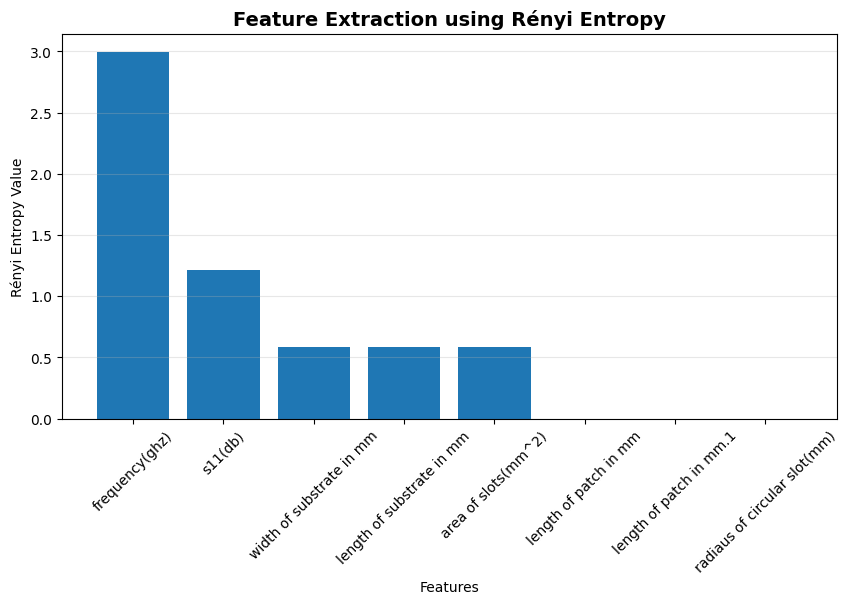

In [ ]:
# ==========================================
# Rényi Entropy Feature Importance Plot
# ==========================================

import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

plt.bar(
    entropy_df["Feature"],
    entropy_df["Renyi_Entropy"]
)


plt.xlabel("Features")
plt.ylabel("Rényi Entropy Value")

plt.title(
    "Feature Extraction using Rényi Entropy",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# **Feature Selection**

In [ ]:
# ==========================================
# CPO Feature Selection (Without Target)
# ==========================================

import numpy as np
import pandas as pd


# Select numerical features
X = df.select_dtypes(include=['int64','float64'])

feature_names = X.columns


# ==============================
# Fitness Function using Variance
# ==============================

def fitness(solution):

    selected = np.where(solution == 1)[0]

    if len(selected) == 0:
        return 999


    selected_data = X.iloc[:, selected]


    # Higher variance = more information
    score = selected_data.var().mean()


    # Penalize selecting too many features
    penalty = len(selected) / X.shape[1]


    fitness_value = (
        -score + 0.01 * penalty
    )

    return fitness_value



# ==============================
# Crested Porcupine Optimization
# ==============================

def CPO(population_size, iterations, features):

    population = np.random.randint(
        0,
        2,
        (population_size, features)
    )


    best_solution = None
    best_score = float("inf")


    for iteration in range(iterations):

        for i in range(population_size):

            score = fitness(
                population[i]
            )


            if score < best_score:
                best_score = score
                best_solution = population[i].copy()


        # Update population
        for i in range(population_size):

            if np.random.random() < 0.5:

                population[i] = np.random.randint(
                    0,
                    2,
                    features
                )

            else:

                index = np.random.randint(
                    features
                )

                population[i][index] ^= 1


        print(
            "Iteration:",
            iteration+1,
            "Best Fitness:",
            best_score
        )


    return best_solution



# ==============================
# Run CPO
# ==============================

best_features = CPO(
    population_size=10,
    iterations=20,
    features=X.shape[1]
)



# ==============================
# Selected Features
# ==============================

selected_index = np.where(
    best_features == 1
)[0]


selected_features = feature_names[
    selected_index
]


X_selected = X[
    selected_features
]


print("\nSelected Features:")
print(selected_features)


print("\nOriginal Features:",
      X.shape[1])

print("Selected Features:",
      X_selected.shape[1])

Iteration: 1 Best Fitness: -14.797804480340897
Iteration: 2 Best Fitness: -24.557678832173938
Iteration: 3 Best Fitness: -24.557678832173938
Iteration: 4 Best Fitness: -24.557678832173938
Iteration: 5 Best Fitness: -24.557678832173938
Iteration: 6 Best Fitness: -24.557678832173938
Iteration: 7 Best Fitness: -24.557678832173938
Iteration: 8 Best Fitness: -24.557678832173938
Iteration: 9 Best Fitness: -24.557678832173938
Iteration: 10 Best Fitness: -24.557678832173938
Iteration: 11 Best Fitness: -24.557678832173938
Iteration: 12 Best Fitness: -24.557678832173938
Iteration: 13 Best Fitness: -24.557678832173938
Iteration: 14 Best Fitness: -24.557678832173938
Iteration: 15 Best Fitness: -24.557678832173938
Iteration: 16 Best Fitness: -24.557678832173938
Iteration: 17 Best Fitness: -24.557678832173938
Iteration: 18 Best Fitness: -24.557678832173938
Iteration: 19 Best Fitness: -24.557678832173938
Iteration: 20 Best Fitness: -24.557678832173938

Selected Features:
Index(['width of substrate in

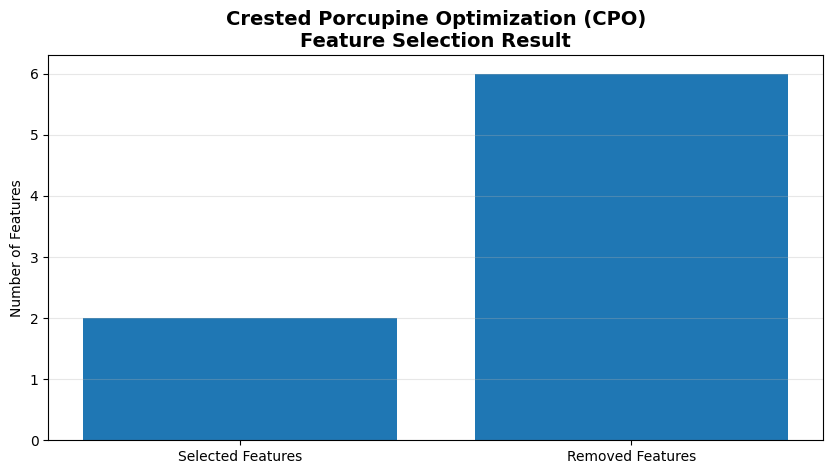

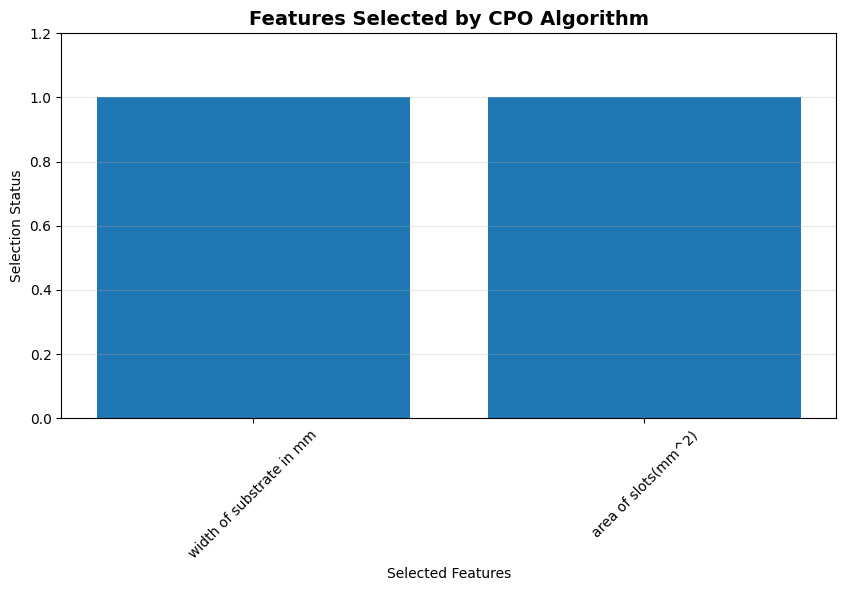

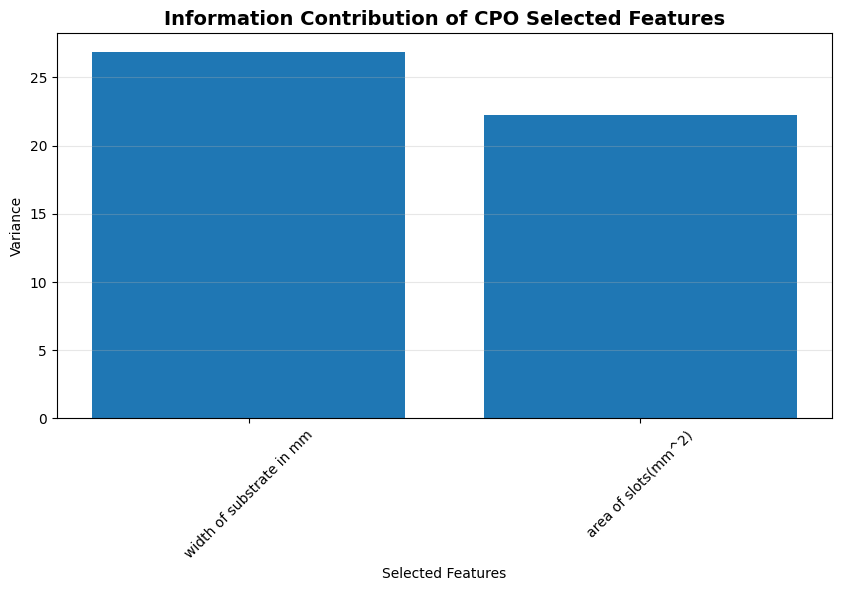

In [ ]:
# ==========================================
# CPO Feature Selection Visualization
# ==========================================

import matplotlib.pyplot as plt


# Create selection status
selection_status = []

for feature in feature_names:
    if feature in selected_features.values:
        selection_status.append("Selected")
    else:
        selection_status.append("Removed")


# Count selected and removed features
selected_count = selection_status.count("Selected")
removed_count = selection_status.count("Removed")


# ==============================
# 1. Feature Selection Bar Chart
# ==============================

plt.figure(figsize=(10,5))

plt.bar(
    ["Selected Features", "Removed Features"],
    [selected_count, removed_count]
)

plt.ylabel("Number of Features")

plt.title(
    "Crested Porcupine Optimization (CPO)\nFeature Selection Result",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()



# ==============================
# 2. Selected Feature Visualization
# ==============================

plt.figure(figsize=(10,5))

plt.bar(
    selected_features,
    [1]*len(selected_features)
)

plt.xlabel("Selected Features")
plt.ylabel("Selection Status")

plt.title(
    "Features Selected by CPO Algorithm",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.ylim(0,1.2)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()



# ==============================
# 3. Feature Importance Based on Variance
# ==============================

variance_values = X[selected_features].var()


plt.figure(figsize=(10,5))

plt.bar(
    variance_values.index,
    variance_values.values
)

plt.xlabel("Selected Features")
plt.ylabel("Variance")

plt.title(
    "Information Contribution of CPO Selected Features",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# **Prediction**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# Reshape for Bi-LSTM
X_train = X_train.reshape(
    X_train.shape[0],
    1,
    X_train.shape[1]
)

X_test = X_test.reshape(
    X_test.shape[0],
    1,
    X_test.shape[1]
)


print("Bi-LSTM Input Shape:")
print(X_train.shape)

Bi-LSTM Input Shape:
(2402, 1, 8)


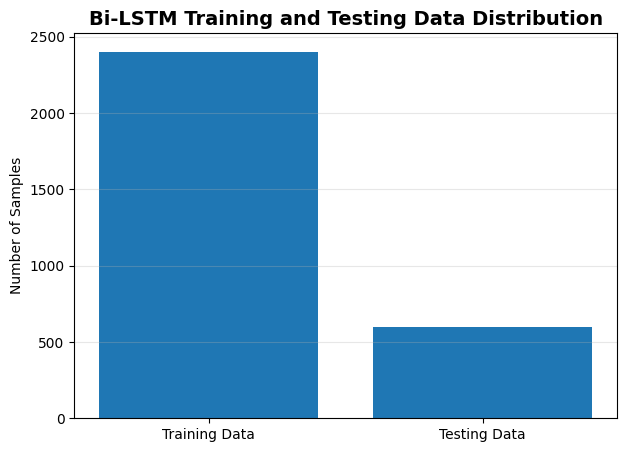

In [ ]:
# ==========================================
# Train Test Split Visualization
# ==========================================

import matplotlib.pyplot as plt


sizes = [
    X_train.shape[0],
    X_test.shape[0]
]

labels = [
    "Training Data",
    "Testing Data"
]


plt.figure(figsize=(7,5))

plt.bar(
    labels,
    sizes
)

plt.ylabel("Number of Samples")

plt.title(
    "Bi-LSTM Training and Testing Data Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

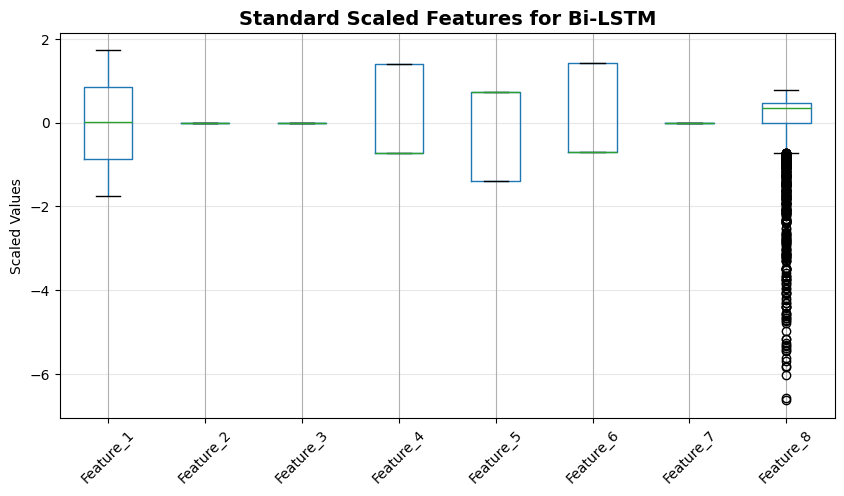

In [ ]:
# ==========================================
# Standard Scaling Visualization
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt


# Convert scaled data for visualization
scaled_df = pd.DataFrame(
    X_train.reshape(
        X_train.shape[0],
        X_train.shape[2]
    ),
    columns=[
        f"Feature_{i+1}"
        for i in range(X_train.shape[2])
    ]
)


plt.figure(figsize=(10,5))

scaled_df.boxplot()

plt.title(
    "Standard Scaled Features for Bi-LSTM",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Scaled Values")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

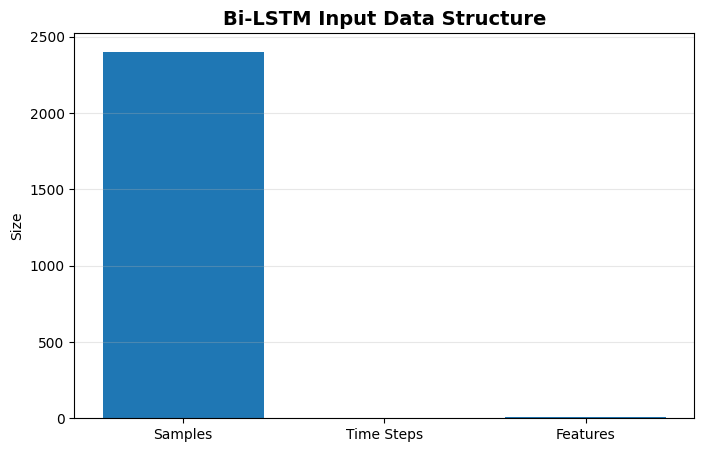

In [ ]:
# ==========================================
# Bi-LSTM Input Dimension Visualization
# ==========================================

import matplotlib.pyplot as plt


dimensions = [
    "Samples",
    "Time Steps",
    "Features"
]

values = [
    X_train.shape[0],
    X_train.shape[1],
    X_train.shape[2]
]


plt.figure(figsize=(8,5))

plt.bar(
    dimensions,
    values
)

plt.ylabel("Size")

plt.title(
    "Bi-LSTM Input Data Structure",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [ ]:
print(df.columns)

Index(['frequency(ghz)', 'length of patch in mm', 'length of patch in mm.1',
       'length of substrate in mm', 'width of substrate in mm',
       'area of slots(mm^2)', 'radiaus of circular slot(mm)', 's11(db)'],
      dtype='object')


In [ ]:
target_column = "s11(db)"

X = df.drop(columns=[target_column])
y = df[target_column]

In [ ]:
# Build the model
model = Sequential()

model.add(Bidirectional(LSTM(64, return_sequences=True),
                        input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(32)))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

NameError: name 'Sequential' is not defined

In [ ]:
y_pred = model.predict(X_test).flatten()

In [ ]:
# Predict S11 values
y_pred = model.predict(X_test)

# Convert to 1D array
y_pred = y_pred.flatten()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("========== Model Performance ==========")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    'r--',
    linewidth=2
)

plt.xlabel("Actual S11 (dB)")
plt.ylabel("Predicted S11 (dB)")
plt.title("Actual vs Predicted S11 using Synaptic Intelligent Bi-LSTM")
plt.grid(True)

plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Bi-LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# MAE Curve
plt.figure(figsize=(8,5))
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.title("Bi-LSTM Mean Absolute Error")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ==========================================
# Bi-LSTM Execution (Training)
# ==========================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Create Bi-LSTM model
model = Sequential([
    Bidirectional(
        LSTM(64, return_sequences=True),
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dropout(0.3),

    Bidirectional(
        LSTM(32)
    ),
    Dropout(0.3),

    Dense(16, activation="relu"),

    # Regression output for S11(dB)
    Dense(1)
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

# Display model architecture
model.summary()

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

print("Bi-LSTM Execution Completed Successfully!")